In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/Users/majazontek/Desktop/UCZELNIA/2 rok/wizualizacja danych/projekt/do wyslania do 23.12.25/barbie_Cleaned.csv')

In [3]:
zdanie = "Was this review helpful? Sign in to vote.Permalink"
df['text'] = df['text'].str.replace(zdanie, "", regex=False)

In [4]:
df['text'] = df['text'].str.split("out of").str[0].str.strip()
df['text'] = df['text'].str.replace("July 2023", "", regex=False).str.strip()

In [5]:
numery='1234567890'
for i in numery:
    df['text'] = df['text'].str.replace(i, "", regex=False).str.strip()
import string
df['text'] = df['text'].str.translate(str.maketrans("", "", string.punctuation))

In [6]:
df['text'] = df['text'].str.lower()

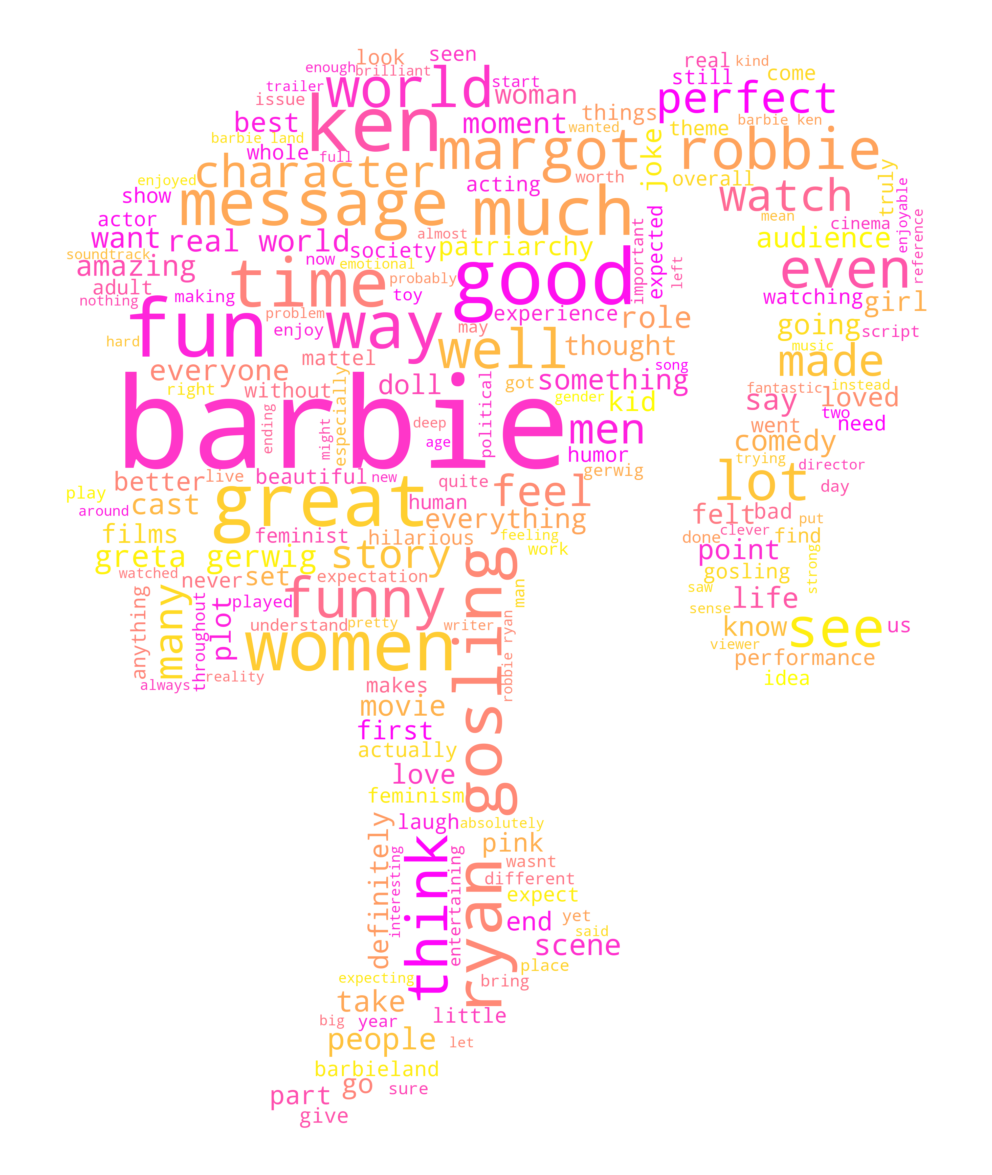

In [12]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

tekst = " ".join(df['text'].tolist())
do_usuniecia = ['bit','throught','thats','dont','cant','u','film','movie','and','to','isnt','warning','spoilers','seem','theres','will','one','didnt','ive','doesnt','im','every','make','thing','though','really']
slowa = tekst.split()
slowa = [w for w in slowa if w.lower() not in do_usuniecia]
tekst = " ".join(slowa)

sciezka_do_pliku = '/Users/majazontek/Desktop/UCZELNIA/2 rok/wizualizacja danych/projekt/do wyslania do 23.12.25/barbie_obrazek.png'

icon_raw = Image.open(sciezka_do_pliku).convert("RGBA")
chmura = WordCloud(
    width=1200,
    height=1200,
    background_color='white',
    colormap='spring',
    mask=maska,
).generate(tekst)

plt.figure(figsize=(15, 15), facecolor='white')
plt.imshow(chmura, interpolation='bilinear')
plt.axis('off')

plt.savefig('barbie_wordcloud_final.png', dpi=300, bbox_inches='tight')
plt.show()